<a href="https://colab.research.google.com/github/SoumajyotiDhut/rare-disease-identification-system/blob/main/notebooks/colab/Day_3_NLP_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
print("✓ HF Token set")

✓ HF Token set


**Setup**

In [1]:
from google.colab import drive, userdata
import os

drive.mount('/content/drive')

# HF Token (if you set it up)
try:
    os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
    print("✓ HF Token set")
except:
    print("⚠ No HF Token — continuing without it")

BASE    = "/content/drive/MyDrive/rare_disease_project"
DATA    = f"{BASE}/data"
RESULTS = f"{BASE}/results"
MODELS  = f"{BASE}/models"

os.makedirs(RESULTS, exist_ok=True)
os.makedirs(MODELS,  exist_ok=True)

import pickle
import numpy as np
import pandas as pd
import torch
import json
from datetime import datetime

# Load splits
with open(f"{DATA}/splits/exp1_train.pkl", "rb") as f:
    exp1_train = pickle.load(f)
with open(f"{DATA}/splits/full_test.pkl", "rb") as f:
    full_test = pickle.load(f)
with open(f"{DATA}/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

NUM_CLASSES = len(le.classes_)

print(f"✓ Setup complete")
print(f"  Device      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"  Train size  : {len(exp1_train)}")
print(f"  Test size   : {len(full_test)}")
print(f"  Num classes : {NUM_CLASSES}")

Mounted at /content/drive
✓ HF Token set
✓ Setup complete
  Device      : Tesla T4
  Train size  : 514
  Test size   : 5339
  Num classes : 795


# Dataset + **DataLoader**

In [2]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.2")
print("✓ Tokenizer loaded")

class SymptomDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts      = df['symptom_text'].tolist()
        self.labels     = df['label'].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Filter test set to only labels seen in training
train_labels = set(exp1_train['label'].unique())
full_test_filtered = full_test[full_test['label'].isin(train_labels)].reset_index(drop=True)

train_dataset = SymptomDataset(exp1_train,        tokenizer)
test_dataset  = SymptomDataset(full_test_filtered, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2)

print(f"✓ DataLoaders ready")
print(f"  Train samples : {len(train_dataset)}")
print(f"  Test samples  : {len(test_dataset)}")
print(f"  Train batches : {len(train_loader)}")
print(f"  Test batches  : {len(test_loader)}")
print(f"  Classes in exp1: {len(train_labels)}")

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✓ Tokenizer loaded
✓ DataLoaders ready
  Train samples : 514
  Test samples  : 2942
  Train batches : 33
  Test batches  : 184
  Classes in exp1: 49


# **Model** **Architecture**

In [3]:
import torch.nn as nn
from transformers import AutoModel

class BioBERTClassifier(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(
            "dmis-lab/biobert-base-cased-v1.2"
        )
        hidden = self.bert.config.hidden_size  # 768

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        out   = self.bert(input_ids=input_ids,
                          attention_mask=attention_mask)
        # CLS token
        cls   = out.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use only classes in exp1
num_exp1_classes = len(train_labels)
model = BioBERTClassifier(num_classes=num_exp1_classes).to(device)

# Remap labels to 0..N for exp1
sorted_labels  = sorted(train_labels)
label_remap    = {old: new for new, old in enumerate(sorted_labels)}
reverse_remap  = {new: old for old, new in label_remap.items()}

print(f"✓ Model built")
print(f"  Classes      : {num_exp1_classes}")
print(f"  Parameters   : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device       : {device}")

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model built
  Classes      : 49
  Parameters   : 108,729,137
  Device       : cuda


# **Remap Labels + Rebuild DataLoader**

In [4]:
# Apply remap to both splits
exp1_remapped       = exp1_train.copy()
exp1_remapped['label'] = exp1_remapped['label'].map(label_remap)

test_remapped       = full_test_filtered.copy()
test_remapped['label'] = test_remapped['label'].map(label_remap)

train_dataset = SymptomDataset(exp1_remapped, tokenizer)
test_dataset  = SymptomDataset(test_remapped,  tokenizer)

train_loader  = DataLoader(train_dataset, batch_size=16,
                            shuffle=True,  num_workers=2)
test_loader   = DataLoader(test_dataset,  batch_size=16,
                            shuffle=False, num_workers=2)

print(f"✓ Labels remapped to 0 → {num_exp1_classes - 1}")
print(f"  Train batches : {len(train_loader)}")
print(f"  Test batches  : {len(test_loader)}")

✓ Labels remapped to 0 → 48
  Train batches : 33
  Test batches  : 184


# **Training Loop**

In [5]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS    = 10
LR        = 2e-5
BEST_ACC  = 0.0

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

train_losses = []
train_accs   = []

print(f"Starting training — {EPOCHS} epochs")
print(f"Total steps : {total_steps}")
print("-" * 50)

for epoch in range(EPOCHS):
    model.train()
    total_loss    = 0
    correct       = 0
    total_samples = 0

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_loss    += loss.item()
        preds          = logits.argmax(dim=1)
        correct       += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    acc      = correct / total_samples * 100

    train_losses.append(avg_loss)
    train_accs.append(acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Train Acc: {acc:.2f}%")

print("-" * 50)
print("✓ Training complete")

Starting training — 10 epochs
Total steps : 330
--------------------------------------------------
Epoch 01/10 | Loss: 3.9040 | Train Acc: 1.75%
Epoch 02/10 | Loss: 3.8335 | Train Acc: 3.50%
Epoch 03/10 | Loss: 3.7780 | Train Acc: 7.00%
Epoch 04/10 | Loss: 3.6970 | Train Acc: 7.98%
Epoch 05/10 | Loss: 3.6191 | Train Acc: 13.42%
Epoch 06/10 | Loss: 3.5235 | Train Acc: 15.95%
Epoch 07/10 | Loss: 3.4603 | Train Acc: 20.62%
Epoch 08/10 | Loss: 3.3959 | Train Acc: 26.46%
Epoch 09/10 | Loss: 3.3761 | Train Acc: 23.74%
Epoch 10/10 | Loss: 3.3267 | Train Acc: 24.32%
--------------------------------------------------
✓ Training complete


In [6]:
from sklearn.metrics import (classification_report,
                              accuracy_score, f1_score)

def evaluate_topk(model, loader, device, k=5):
    model.eval()
    all_preds   = []
    all_labels  = []
    top5_correct = 0
    total        = 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            logits = model(input_ids, attention_mask)

            # Top-1
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Top-K
            topk   = logits.topk(k, dim=1).indices
            for i, lbl in enumerate(labels):
                if lbl in topk[i]:
                    top5_correct += 1
            total += labels.size(0)

    acc      = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds,
                        average='macro',  zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds,
                           average='weighted', zero_division=0)
    top5_acc = top5_correct / total

    return {
        "accuracy"    : round(acc * 100, 2),
        "f1_macro"    : round(f1_macro * 100, 2),
        "f1_weighted" : round(f1_weighted * 100, 2),
        "top5_accuracy": round(top5_acc * 100, 2),
        "total_samples": total
    }

print("Evaluating on test set...")
metrics = evaluate_topk(model, test_loader, device, k=5)

print("\n" + "=" * 50)
print("EXP 1 — NLP BASELINE RESULTS (5-10% scarcity)")
print("=" * 50)
print(f"  Accuracy     : {metrics['accuracy']}%")
print(f"  F1 Macro     : {metrics['f1_macro']}%")
print(f"  F1 Weighted  : {metrics['f1_weighted']}%")
print(f"  Top-5 Acc    : {metrics['top5_accuracy']}%")
print(f"  Test samples : {metrics['total_samples']}")

Evaluating on test set...

EXP 1 — NLP BASELINE RESULTS (5-10% scarcity)
  Accuracy     : 10.16%
  F1 Macro     : 2.16%
  F1 Weighted  : 8.97%
  Top-5 Acc    : 17.74%
  Test samples : 2942


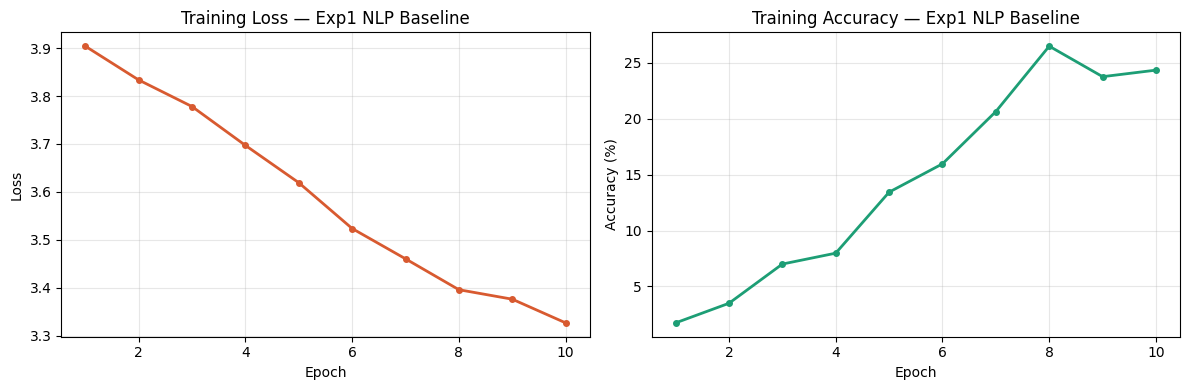

✓ Training curves saved


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS+1), train_losses,
             color='#D85A30', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Training Loss — Exp1 NLP Baseline')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS+1), train_accs,
             color='#1D9E75', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Training Accuracy — Exp1 NLP Baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS}/day3_nlp_baseline_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Training curves saved")